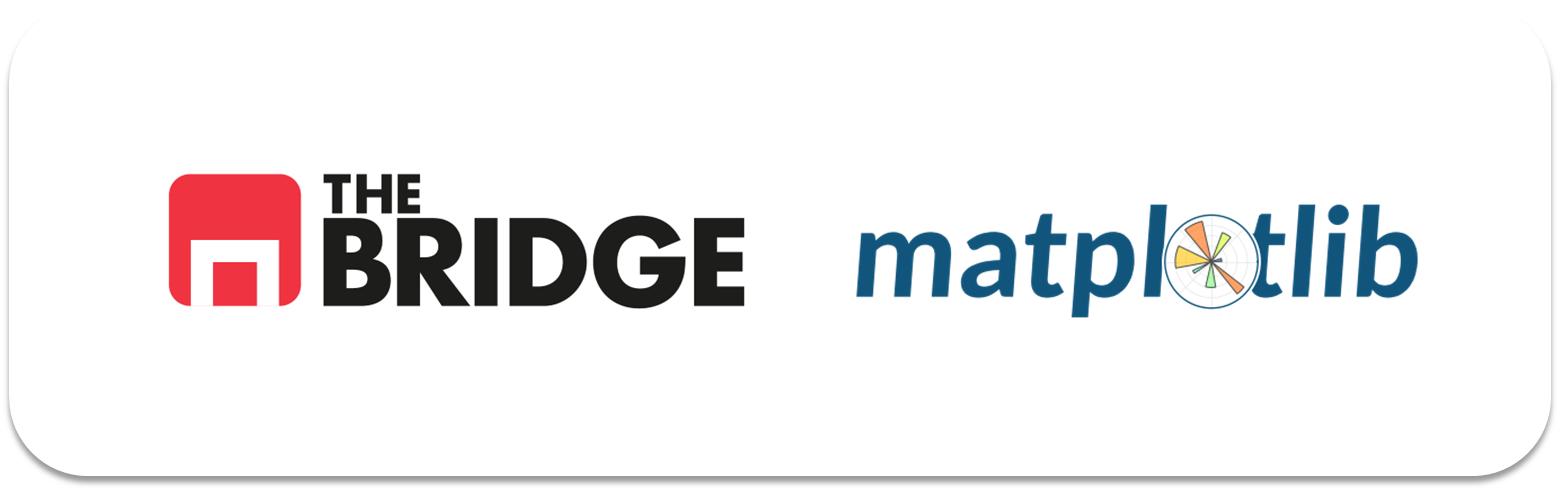

## PRACTICA OBLIGATORIA: **Visualización Básica**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de construcción de gráficas. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.options.mode.copy_on_write = True

### Ejercicio 1

#### #1.1

- Carga el dataset de ciudades de California que está en la ruta "./data/california_cities.csv".  
- Muestra parte de su contenido y su descripción.  
- Deshazte de las filas con nulos.

In [6]:
df = pd.read_csv("./data/california_cities.csv", index_col = 0) # Con esto convierto la columna Unnamed en el índice del df

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 482 entries, 0 to 481
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   city                482 non-null    object 
 1   latd                482 non-null    float64
 2   longd               482 non-null    float64
 3   elevation_m         434 non-null    float64
 4   elevation_ft        470 non-null    float64
 5   population_total    482 non-null    int64  
 6   area_total_sq_mi    480 non-null    float64
 7   area_land_sq_mi     482 non-null    float64
 8   area_water_sq_mi    481 non-null    float64
 9   area_total_km2      477 non-null    float64
 10  area_land_km2       478 non-null    float64
 11  area_water_km2      478 non-null    float64
 12  area_water_percent  477 non-null    float64
dtypes: float64(11), int64(1), object(1)
memory usage: 52.7+ KB


In [11]:
df.isna().sum().sort_values(ascending=False)

# Aquí nos damos cuenta que que podemos recuperar parte de las filas de elevation_m...
# ... con el dato de elevation_ft porque existe una relación entre ft y metros

elevation_m           48
elevation_ft          12
area_water_percent     5
area_total_km2         5
area_water_km2         4
area_land_km2          4
area_total_sq_mi       2
area_water_sq_mi       1
city                   0
latd                   0
longd                  0
area_land_sq_mi        0
population_total       0
dtype: int64

In [ ]:
df["elevation_m_from_ft"] = df.elevation_ft * 0.3048 # conversión de pies a metros

In [ ]:
abs(df["elevation_m"] - df["elevation_m_from_ft"]).nlargest(20) 

# Valores más grandes de diferencias entre la nueva columna creada y su origen inicial en metros

115    326.0336
362    280.6752
53     241.4760
239     70.3904
337     53.7800
72      38.8640
210     26.0800
318     23.9896
262     15.5504
305     11.8880
377      7.7392
365      5.2000
367      5.0856
149      4.5536
69       3.6368
193      3.2840
112      3.1560
352      3.1048
209      3.0688
446      2.7120
dtype: float64

In [ ]:
df.loc[df["elevation_m"].isna(), "elevation_m"] = df.loc[df["elevation_m"].isna(), "elevation_m_from_ft"]

# Con esto solo sustituyo los nulos con la nueva columna

In [22]:
df = df.dropna()
df

,city,latd,longd,elevation_m,elevation_ft,population_total,area_total_sq_mi,area_land_sq_mi,area_water_sq_mi,area_total_km2,area_land_km2,area_water_km2,area_water_percent,elevation_m_from_ft
0,Adelanto,34.576111,-117.432778,875.0000,2871.0,31765,56.027,56.009,0.018,145.107,145.062,0.046,0.03,875.0808
1,AgouraHills,34.153333,-118.761667,281.0000,922.0,20330,7.822,7.793,0.029,20.260,20.184,0.076,0.37,281.0256
2,Alameda,37.756111,-122.274444,10.0584,33.0,75467,22.960,10.611,12.349,59.465,27.482,31.983,53.79,10.0584
3,Albany,37.886944,-122.297778,13.1064,43.0,18969,5.465,1.788,3.677,14.155,4.632,9.524,67.28,13.1064
4,Alhambra,34.081944,-118.135000,150.0000,492.0,83089,7.632,7.631,0.001,19.766,19.763,0.003,0.01,149.9616
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
477,Yountville,38.403056,-122.362222,30.0000,98.0,2933,1.531,1.531,0.000,3.966,3.966,0.000,0.00,29.8704
478,Yreka,41.726667,-122.637500,787.0000,2582.0,7765,10.053,9.980,0.073,26.036,25.847,0.188,0.72,786.9936
479,YubaCity,39.134722,-121.626111,18.0000,59.0,64925,14.656,14.578,0.078,37.959,37.758,0.201,0.53,17.9832
480,Yucaipa,34.030278,-117.048611,798.0000,2618.0,51367,27.893,27.888,0.005,72.244,72.231,0.013,0.02,797.9664


#### #1.2  

Recrea la siguiente figura, para ello construye en apartados separados cada gráfico y luego haz un apartado en el que se junten los cuatro.  

Las figuras son:
1. Las ciudades más pobladas, con los numeros de las poblaciones (tendrás que usar texto y recordar que para centrarlos se necesita poner el argumento `ha` a "center"). (Colores: azul, gris, aceituna, marrón, con trasparencia)  

2. Histograma del área total ocupada por las ciudades. (50 bins, fuente = "Bradley Hand ITC", tamaño 18, color azul acero o "steelblue")
3. El scatter de área de agua de un ciudad con su poblacion.
4. El boxplot de la altura de las ciudades.

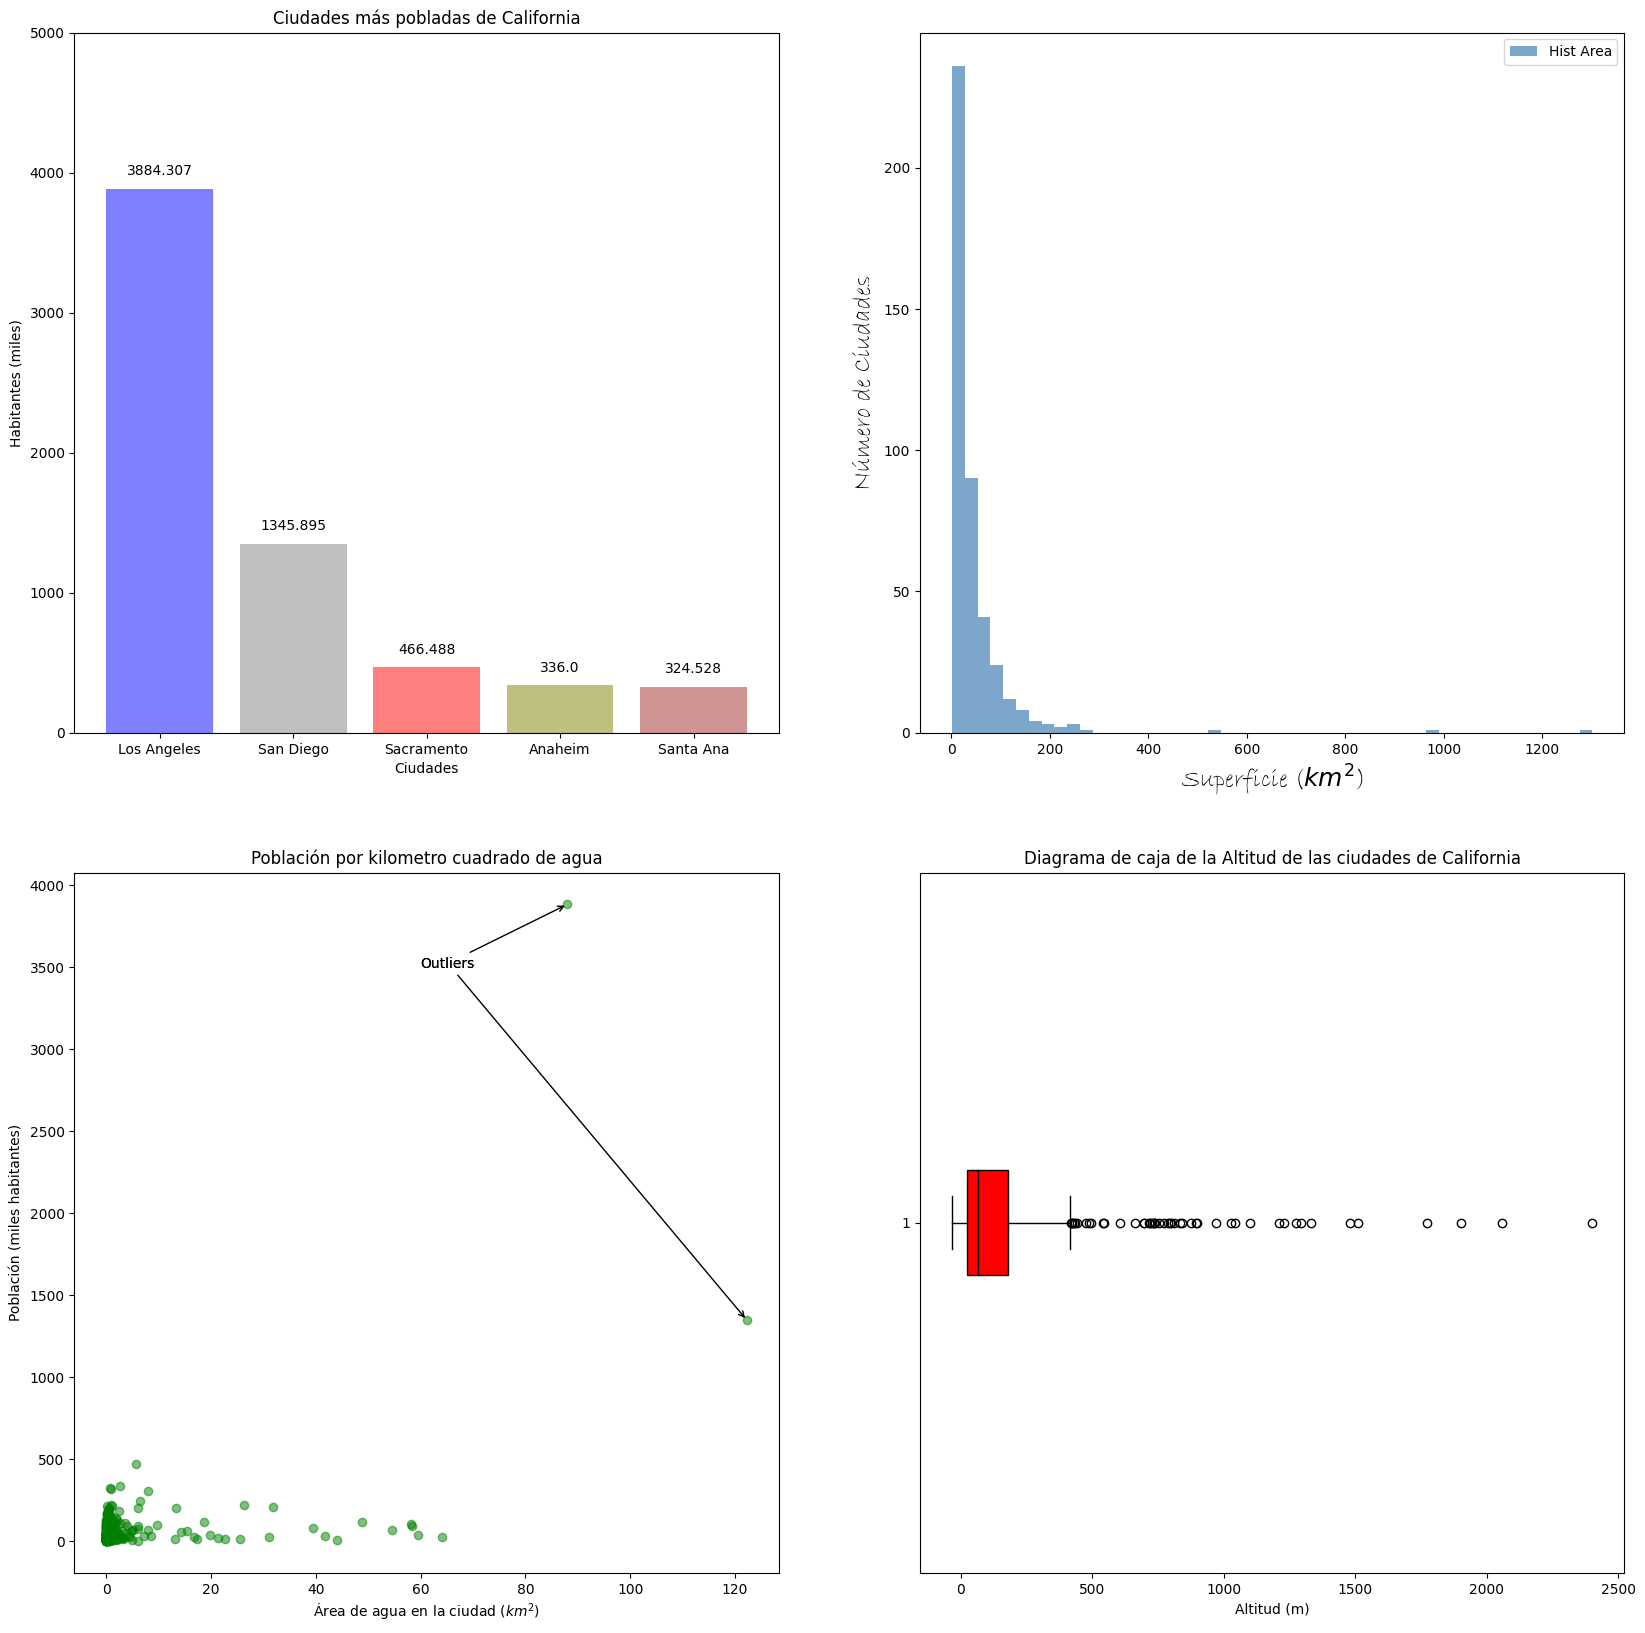

#### #1.3

Graba la figura en un archivo .png y sube el archivo a tu repositorio personal junto con el notebook.

In [31]:
# Esta función la usamos luego para las gráficas

def separa_nombre(nombre):
    nuevo = nombre[0]
    for letra in nombre[1:]:
        if letra == letra.upper():
            nuevo += " "
        nuevo += letra
    return nuevo

findfont: Font family 'Bradley Hand ITC' not found.
findfont: Font family ['Bradley Hand ITC'] not found. Falling back to DejaVu Sans.
findfont: Font family 'Bradley Hand ITC' not found.
findfont: Font family 'Bradley Hand ITC' not found.
findfont: Font family 'Bradley Hand ITC' not found.
findfont: Font family 'Bradley Hand ITC' not found.


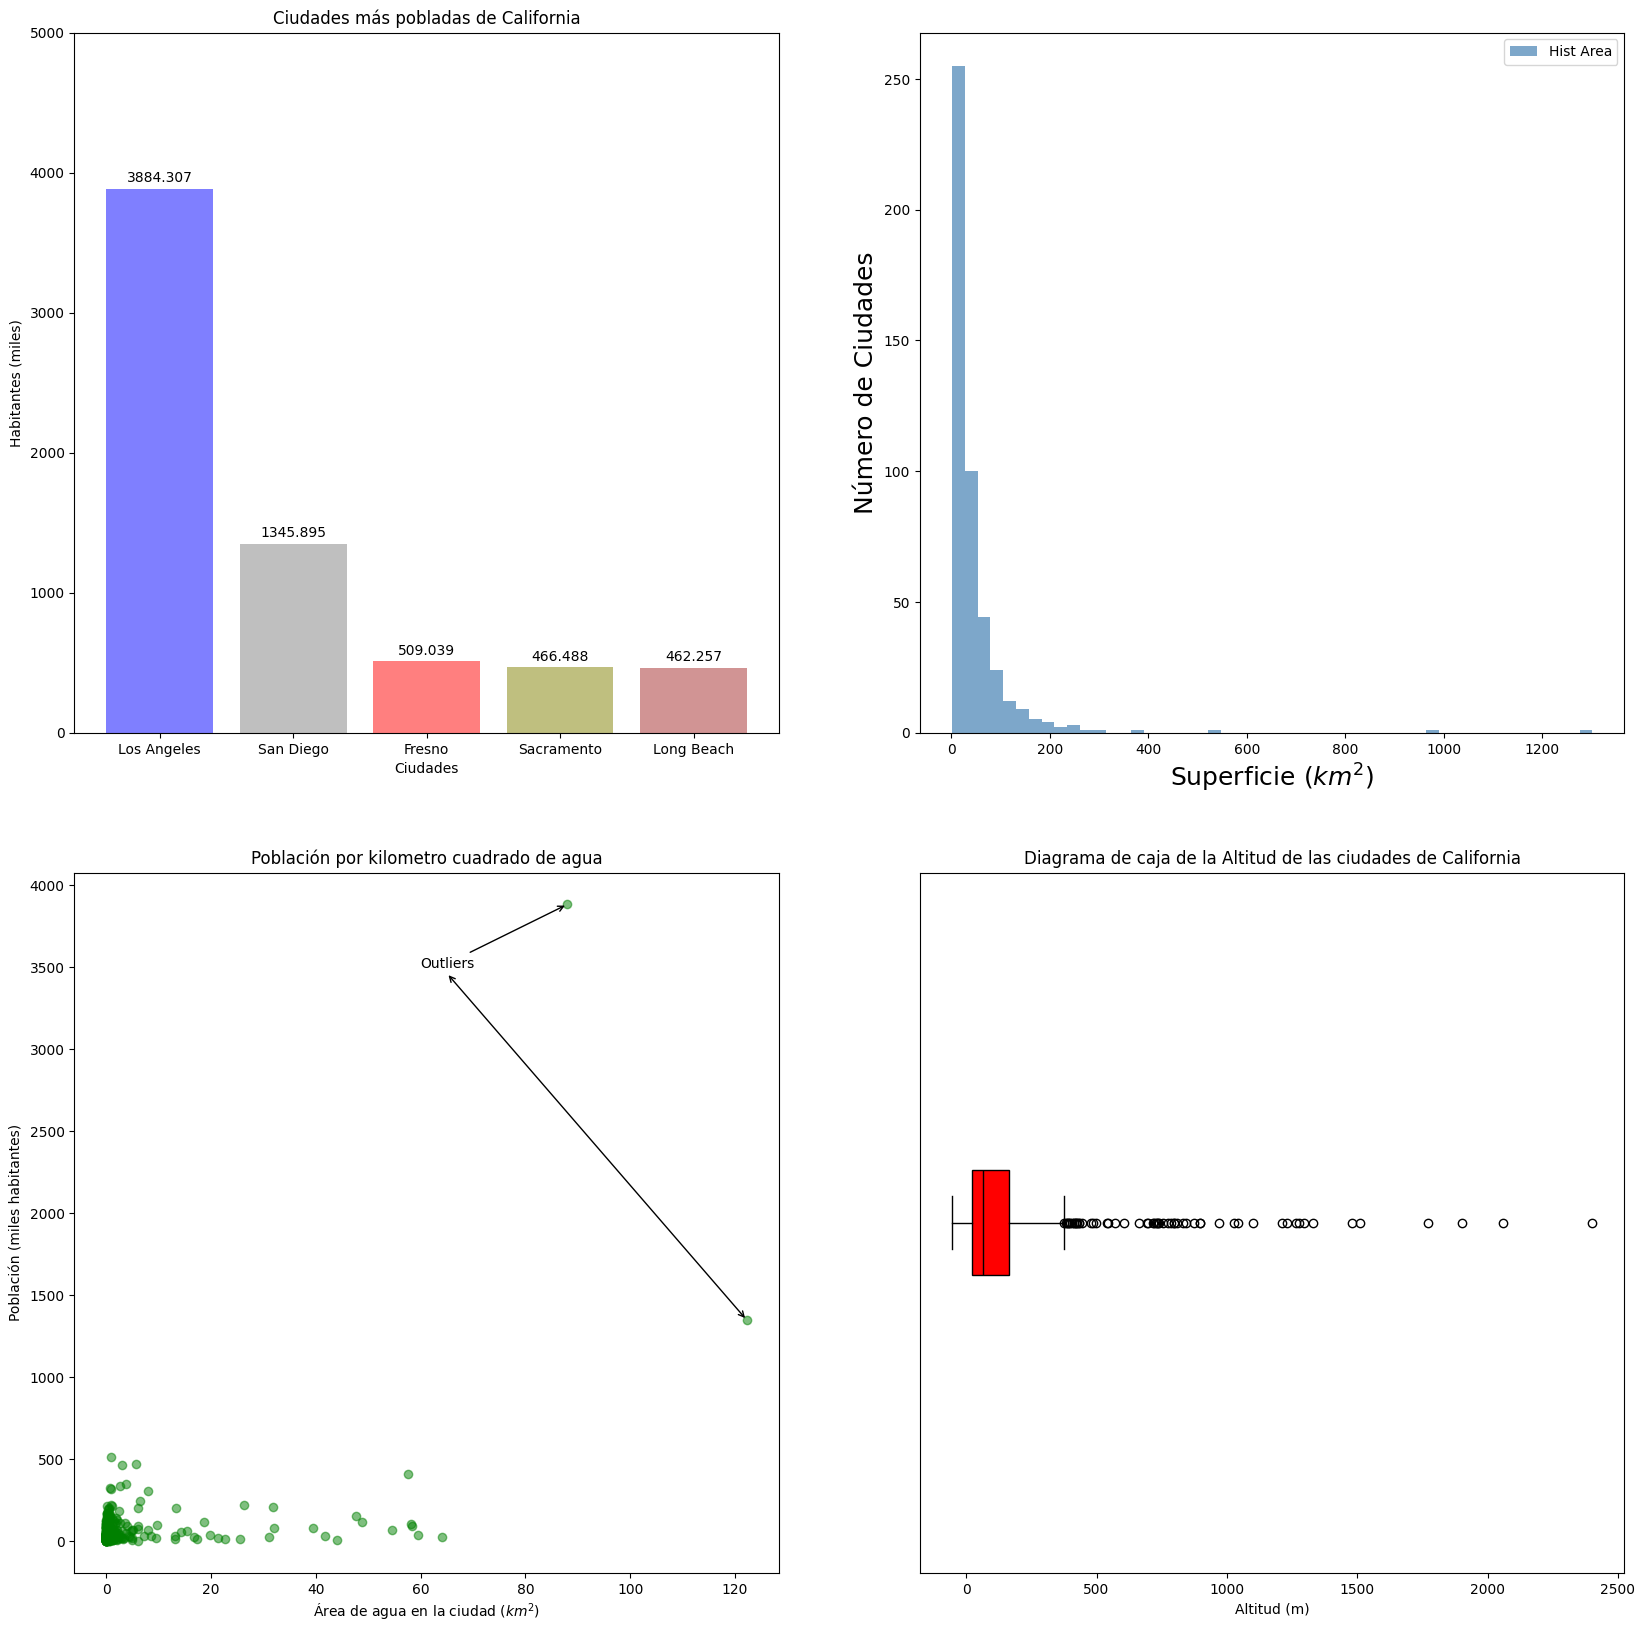

In [30]:
# Todas juntas
plt.figure(figsize=(20,20))

# Primera figura
plt.subplot(2,2,1)

ciudades_mas_pobladas = df.loc[df.population_total.nlargest(5).index,["city","population_total"]]
ciudades = [ separa_nombre(ciudad) for ciudad in ciudades_mas_pobladas["city"].to_list()]
colores = ["blue","gray","red","olive","brown"]

plt.bar(x= ciudades, height= ciudades_mas_pobladas["population_total"]/1000, color = colores, alpha = 0.5)

plt.ylim([0,5000])
plt.ylabel("Habitantes (miles)")
plt.xlabel("Ciudades")
plt.title("Ciudades más pobladas de California")

ciudades_mas_pobladas.set_index("city", inplace = True)
for indice, ciudad in enumerate(ciudades_mas_pobladas.index):
    poblacion = ciudades_mas_pobladas.loc[ciudad,"population_total"]/1000
    plt.text(ciudades[indice], poblacion + 50, f"{poblacion}", ha = "center")

# Segunda figura
plt.subplot(2,2,2)

plt.hist(df["area_total_km2"], color = "steelblue", alpha = 0.7, bins = 50, label = "Hist Area")

plt.xlabel("Superficie ($km^2$)", fontdict = dict(family= "Bradley Hand ITC", size = 18))
plt.ylabel("Número de Ciudades", fontdict= dict(family = "Bradley Hand ITC", size = 18))
plt.legend()

# Tercera figura
plt.subplot(2,2,3)

plt.scatter(df["area_water_km2"], df["population_total"]/1000, alpha = 0.5, color = "green")

plt.xlabel("Área de agua en la ciudad ($km^2$)")
plt.ylabel("Población (miles habitantes)")
plt.title("Población por kilometro cuadrado de agua")

outlier_1_y = ciudades_mas_pobladas.population_total.max()
outlier_2_y = ciudades_mas_pobladas.population_total.nlargest(2).iloc[1]
outlier_1_x = df.loc[df.population_total == outlier_1_y,"area_water_km2"].values[0]
outlier_2_x = df.loc[df.population_total == outlier_2_y,"area_water_km2"].values[0]

xytext= (60,3500)
text = "Outliers"

plt.annotate(xy= (outlier_1_x,outlier_1_y/1000), xytext= xytext, text = text, arrowprops= dict(arrowstyle = "->"))

plt.annotate(xy= (outlier_2_x,outlier_2_y/1000), xytext= xytext, text = " " * len(text), arrowprops= dict(arrowstyle = "<->"))

# Cuarta figura
plt.subplot(2,2,4)

plt.boxplot(df["elevation_m"], vert = False, boxprops = dict(facecolor = "red"), medianprops = dict(color= "black"),
            patch_artist= True )

plt.xlabel("Altitud (m)")
plt.title("Diagrama de caja de la Altitud de las ciudades de California")
plt.yticks([])

plt.show()